In [54]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

In [55]:
filelist_red = ["Vid3.0_TRACKED-RED.csv","Vid3.1_TRACKED-RED.csv","Vid3.2_TRACKED-RED.csv","Vid3.3_TRACKED-RED.csv","Vid3.4_TRACKED-RED.csv","Vid3.5_TRACKED-RED.csv"]
filelist_green = ["Vid3.0_TRACKED-GREEN.csv","Vid3.1_TRACKED-GREEN.csv","Vid3.2_TRACKED-GREEN.csv","Vid3.3_TRACKED-GREEN.csv","Vid3.4_TRACKED-GREEN.csv","Vid3.5_TRACKED-GREEN.csv"]
file = pd.read_csv("NightCap_2677A448_test.csv") #Rood
file2 = pd.read_csv("NightCap_2677A448_test_Green.csv") # Groen

1134.62674397239 -811.2071900526122 490.62336686673865


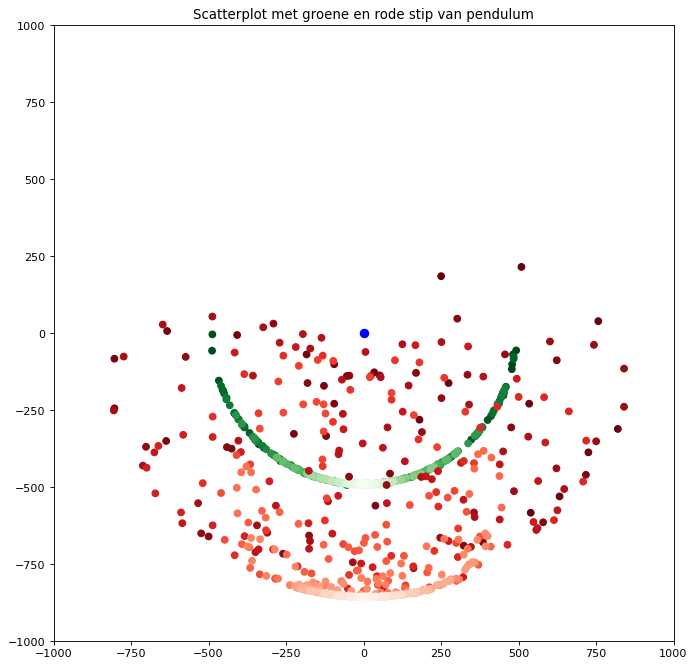

<function matplotlib.pyplot.show(close=None, block=None)>

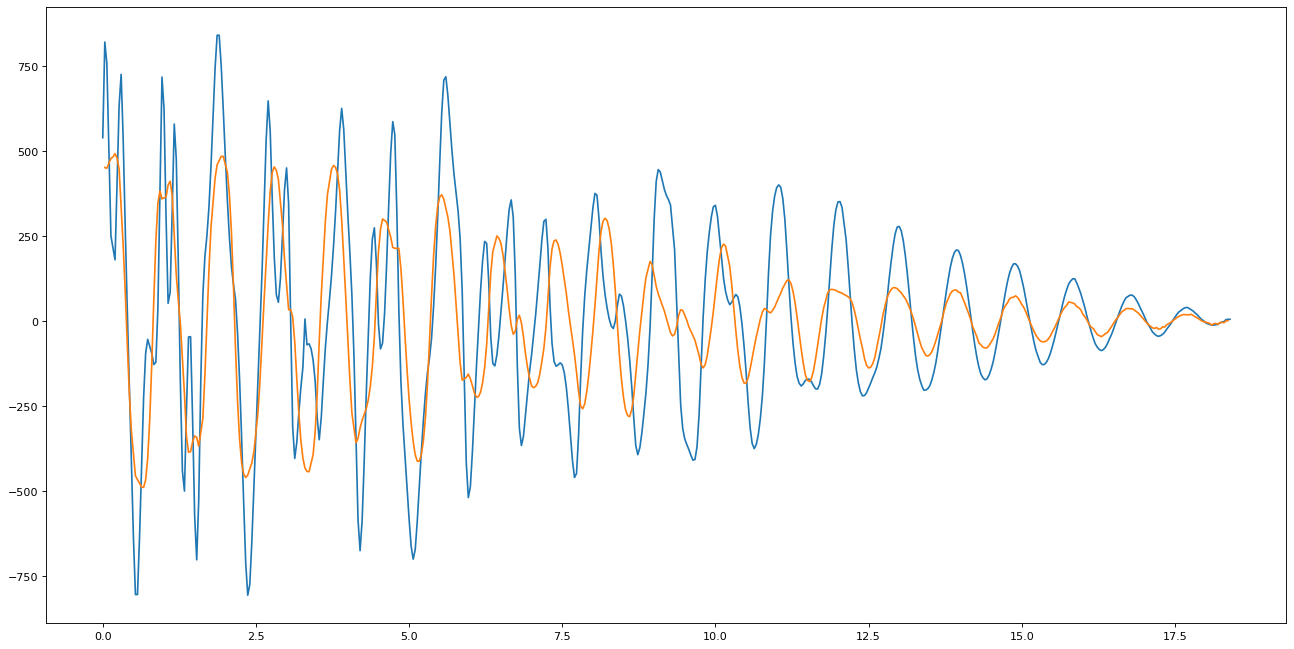

In [56]:
t = file["time_s"].to_numpy()
x = file["x"].to_numpy()
y = -file["y"].to_numpy()

mask = np.isfinite(t) & np.isfinite(x) & np.isfinite(y)
t = t[mask]
x= x[mask]
y = y[mask]

t2 = file2["time_s"].to_numpy()
x2 = file2["x"].to_numpy()
y2 = -file2["y"].to_numpy()

mask = np.isfinite(t2) & np.isfinite(x2) & np.isfinite(y2)
t2 = t2[mask]
x2= x2[mask]
y2 = y2[mask]


#Het vinden van het middelpunt mbv de cirkel gemaakt door de groene stip
def circlefit(data, x_0, y_0, R):
    n = len(data) // 2
    x = data[:n]
    y = data[n:]

    return np.sqrt((x-x_0)**2 + (y-y_0)**2) - R

data = np.concatenate([x2, y2])
target = np.zeros(len(x2))

popt, cov = curve_fit(circlefit,data,target)
x_0 = popt[0]
y_0 = popt[1]
R   = popt[2]
print(x_0,y_0,R)

x = x-x_0
y = y-y_0
x2 = x2-x_0
y2 = y2-y_0

plt.figure(figsize=(10,10), dpi=80)
plt.title("Scatterplot met groene en rode stip van pendulum")
plt.scatter(x2, y2, c=-t2, cmap='Greens')
plt.scatter(x, y, c=-t, cmap='Reds')
plt.plot(0,0,"b.", markersize = 15)
plt.xlim(-1000,+1000)
plt.ylim(-1000,+1000)
plt.show()


plt.figure(figsize=(20,10), dpi=80)
plt.plot(t,x)
plt.plot(t2,x2)
plt.show



<function matplotlib.pyplot.show(close=None, block=None)>

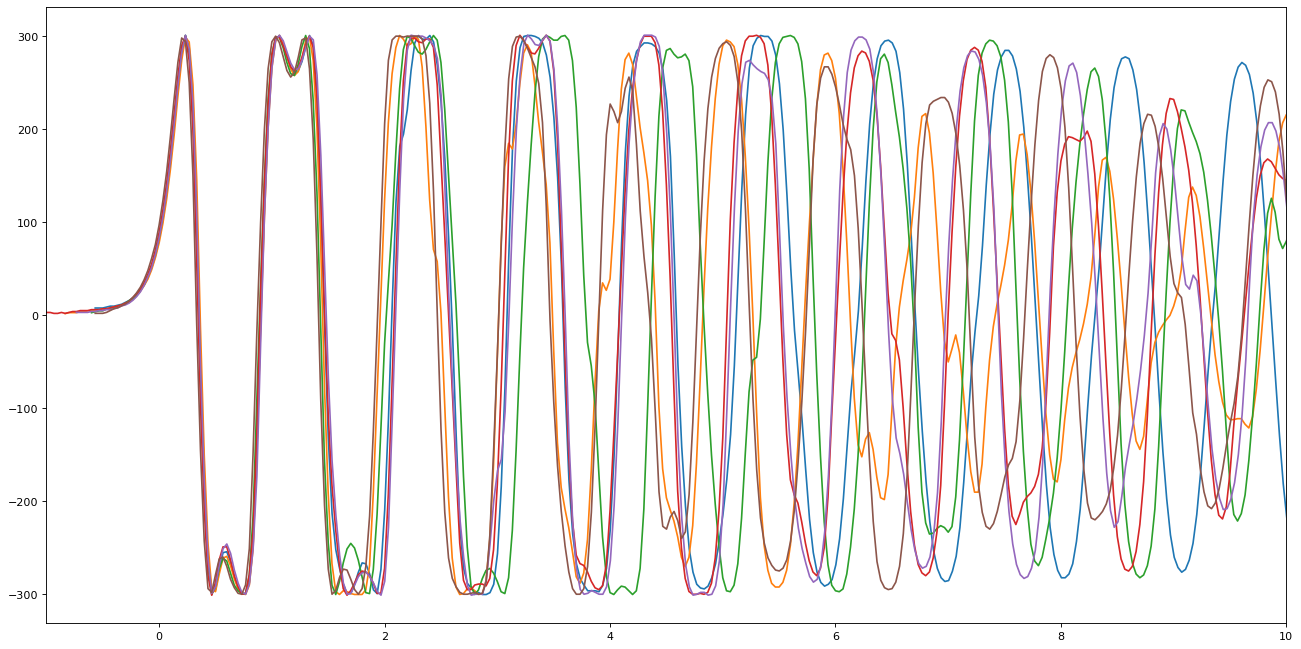

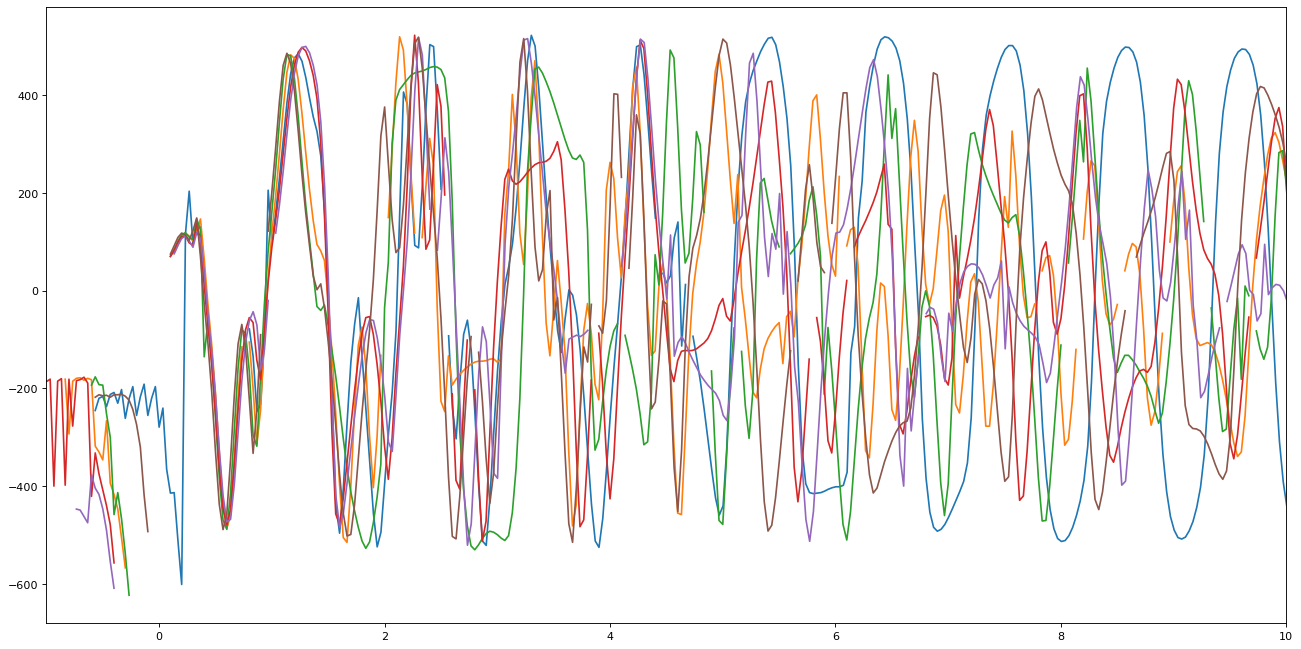

In [57]:

x_0_array = np.array([])
y_0_array = np.array([])
min_inx_array = np.array([])
n=0
y_drempel = 290

plt.figure(figsize=(20,10), dpi=80)
for name in filelist_green:
    file = pd.read_csv(name) 
    t2 = file["time_s"].to_numpy()
    x2 = file["x"].to_numpy()
    y2 = -file["y"].to_numpy()
    

    def circlefit(data, x_0, y_0, R):
        n = len(data) // 2
        x = data[:n]
        y = data[n:]
        return np.sqrt((x-x_0)**2 + (y-y_0)**2) - R
    data = np.concatenate([x2, y2])
    target = np.zeros(len(x2))
    popt, cov = curve_fit(circlefit,data,target)
    x_0 = popt[0]
    y_0 = popt[1]
    R   = popt[2]
    x = x - x_0
    y = y - y_0
    x2 = x2 - x_0
    y2 = y2 - y_0
    x_0_array = np.append(x_0_array,x_0)
    y_0_array = np.append(y_0_array,y_0)
    indx = np.where(y2 < y_drempel)[0]
    drempel_idx = indx[0] 
    t2 = t2 - t2[drempel_idx] 
    min_inx_array = np.append(min_inx_array,drempel_idx)
    plt.plot(t2,x2)
plt.xlim(-1,10)
plt.show

plt.figure(figsize=(20,10), dpi=80)
for name in filelist_red:
    file = pd.read_csv(name) #Rood
    t = file["time_s"].to_numpy()
    x = file["x"].to_numpy() - x_0_array[n]
    y = -file["y"].to_numpy() - y_0_array[n]
    t = t - t[int(min_inx_array[n])]
    plt.plot(t,x)
    n += 1
plt.xlim(-1,10)
plt.show

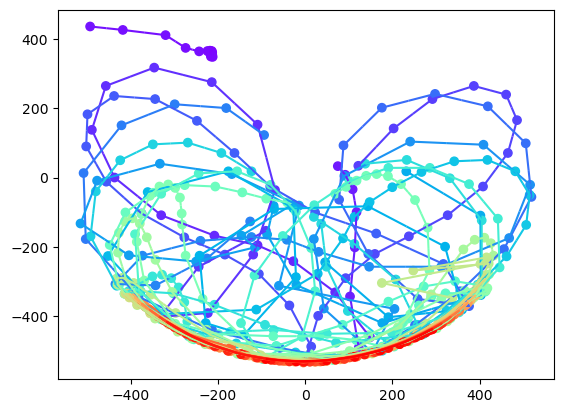

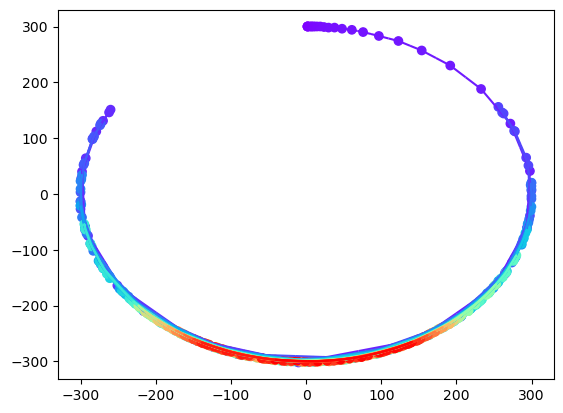

In [58]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

from matplotlib.collections import LineCollection
c = t 

def colored_line(x, y, c, ax=None, **lc_kwargs):
    if "array" in lc_kwargs:
        warnings.warn(
            'The provided "array" keyword argument will be overridden',
            UserWarning,
            stacklevel=2,
        )

    xy = np.stack((x, y), axis=-1)
    xy_mid = np.concat(
        (xy[0, :][None, :], (xy[:-1, :] + xy[1:, :]) / 2, xy[-1, :][None, :]), axis=0
    )
    segments = np.stack((xy_mid[:-1, :], xy, xy_mid[1:, :]), axis=-2)
    # Note that
    # segments[0, :, :] is [xy[0, :], xy[0, :], (xy[0, :] + xy[1, :]) / 2]
    # segments[i, :, :] is [(xy[i - 1, :] + xy[i, :]) / 2, xy[i, :],
    #     (xy[i, :] + xy[i + 1, :]) / 2] if i not in {0, len(x) - 1}
    # segments[-1, :, :] is [(xy[-2, :] + xy[-1, :]) / 2, xy[-1, :], xy[-1, :]]

    lc_kwargs["array"] = c
    lc = LineCollection(segments, **lc_kwargs)

    # Plot the line collection to the axes
    ax = ax or plt.gca()
    ax.add_collection(lc)

    return lc


color = np.linspace(0, 2, t.size)
fig, ax = plt.subplots()
ax.scatter(x, y, c=t, cmap='rainbow')
colored_line(x, y, c=t, ax=ax, cmap='rainbow')

color = np.linspace(0, 2, t2.size)
fig, ax = plt.subplots()
ax.scatter(x2, y2, c=t2, cmap='rainbow')
colored_line(x2, y2, c=t2, ax=ax, cmap='rainbow')


plt.show()